# Per-Event Storm Tracking

Visualize the **spatiotemporal evolution + fitted ellipse** of a *single* storm event:
a storm-track overview (centroid trajectory, ellipses, mean-direction vector) and a grid
of per-time-step rainfall panels.

The reported mean direction is the direction of motion in **degrees counterclockwise from east**
(0° = E, 90° = N), relative to true east/north (geodesic on WGS84, not EPSG:2163 grid north).

Same thing from the command line:
```bash
python run_diagnostics.py event --config configs/testing_data.json --storm 100
```

In [1]:
# Make the package importable and pick up code edits without a manual kernel restart:
# chdir to the repo root, then drop cached stormcatalog_analyzer modules so the imports
# below are re-read fresh from disk on every re-run.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]
print("repo root:", root)

repo root: /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer


## 1. Load config and choose a storm

In [2]:
from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline

cfg = load_config("configs/testing_data.json")

# A storm filename, a unique substring, or a numeric storm id:
storm = "394"

/opt/anaconda3/envs/storm-motion-analyzer/lib/python3.10/site-packages/mpu/string.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Track the event and render its figures
Saved under `<output_dir>/<domain>/StormTrack/` and `.../StormTimeSteps/`.

In [3]:
figs = pipeline.generate_event_diagnostics(cfg, storm)

The longest storm has a valid duration of 18 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2014-09-09T20:00:00.000000000 to 2014-09-10T13:00:00.000000000
Selected storm duration 18 hours
Saved 2 figures for IOWA_Domain.nc_storm_394_20140909.nc:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTrack/storm_track_394.png
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTimeSteps/storm_step_394.png


## 3. Display

storm_track_394.png


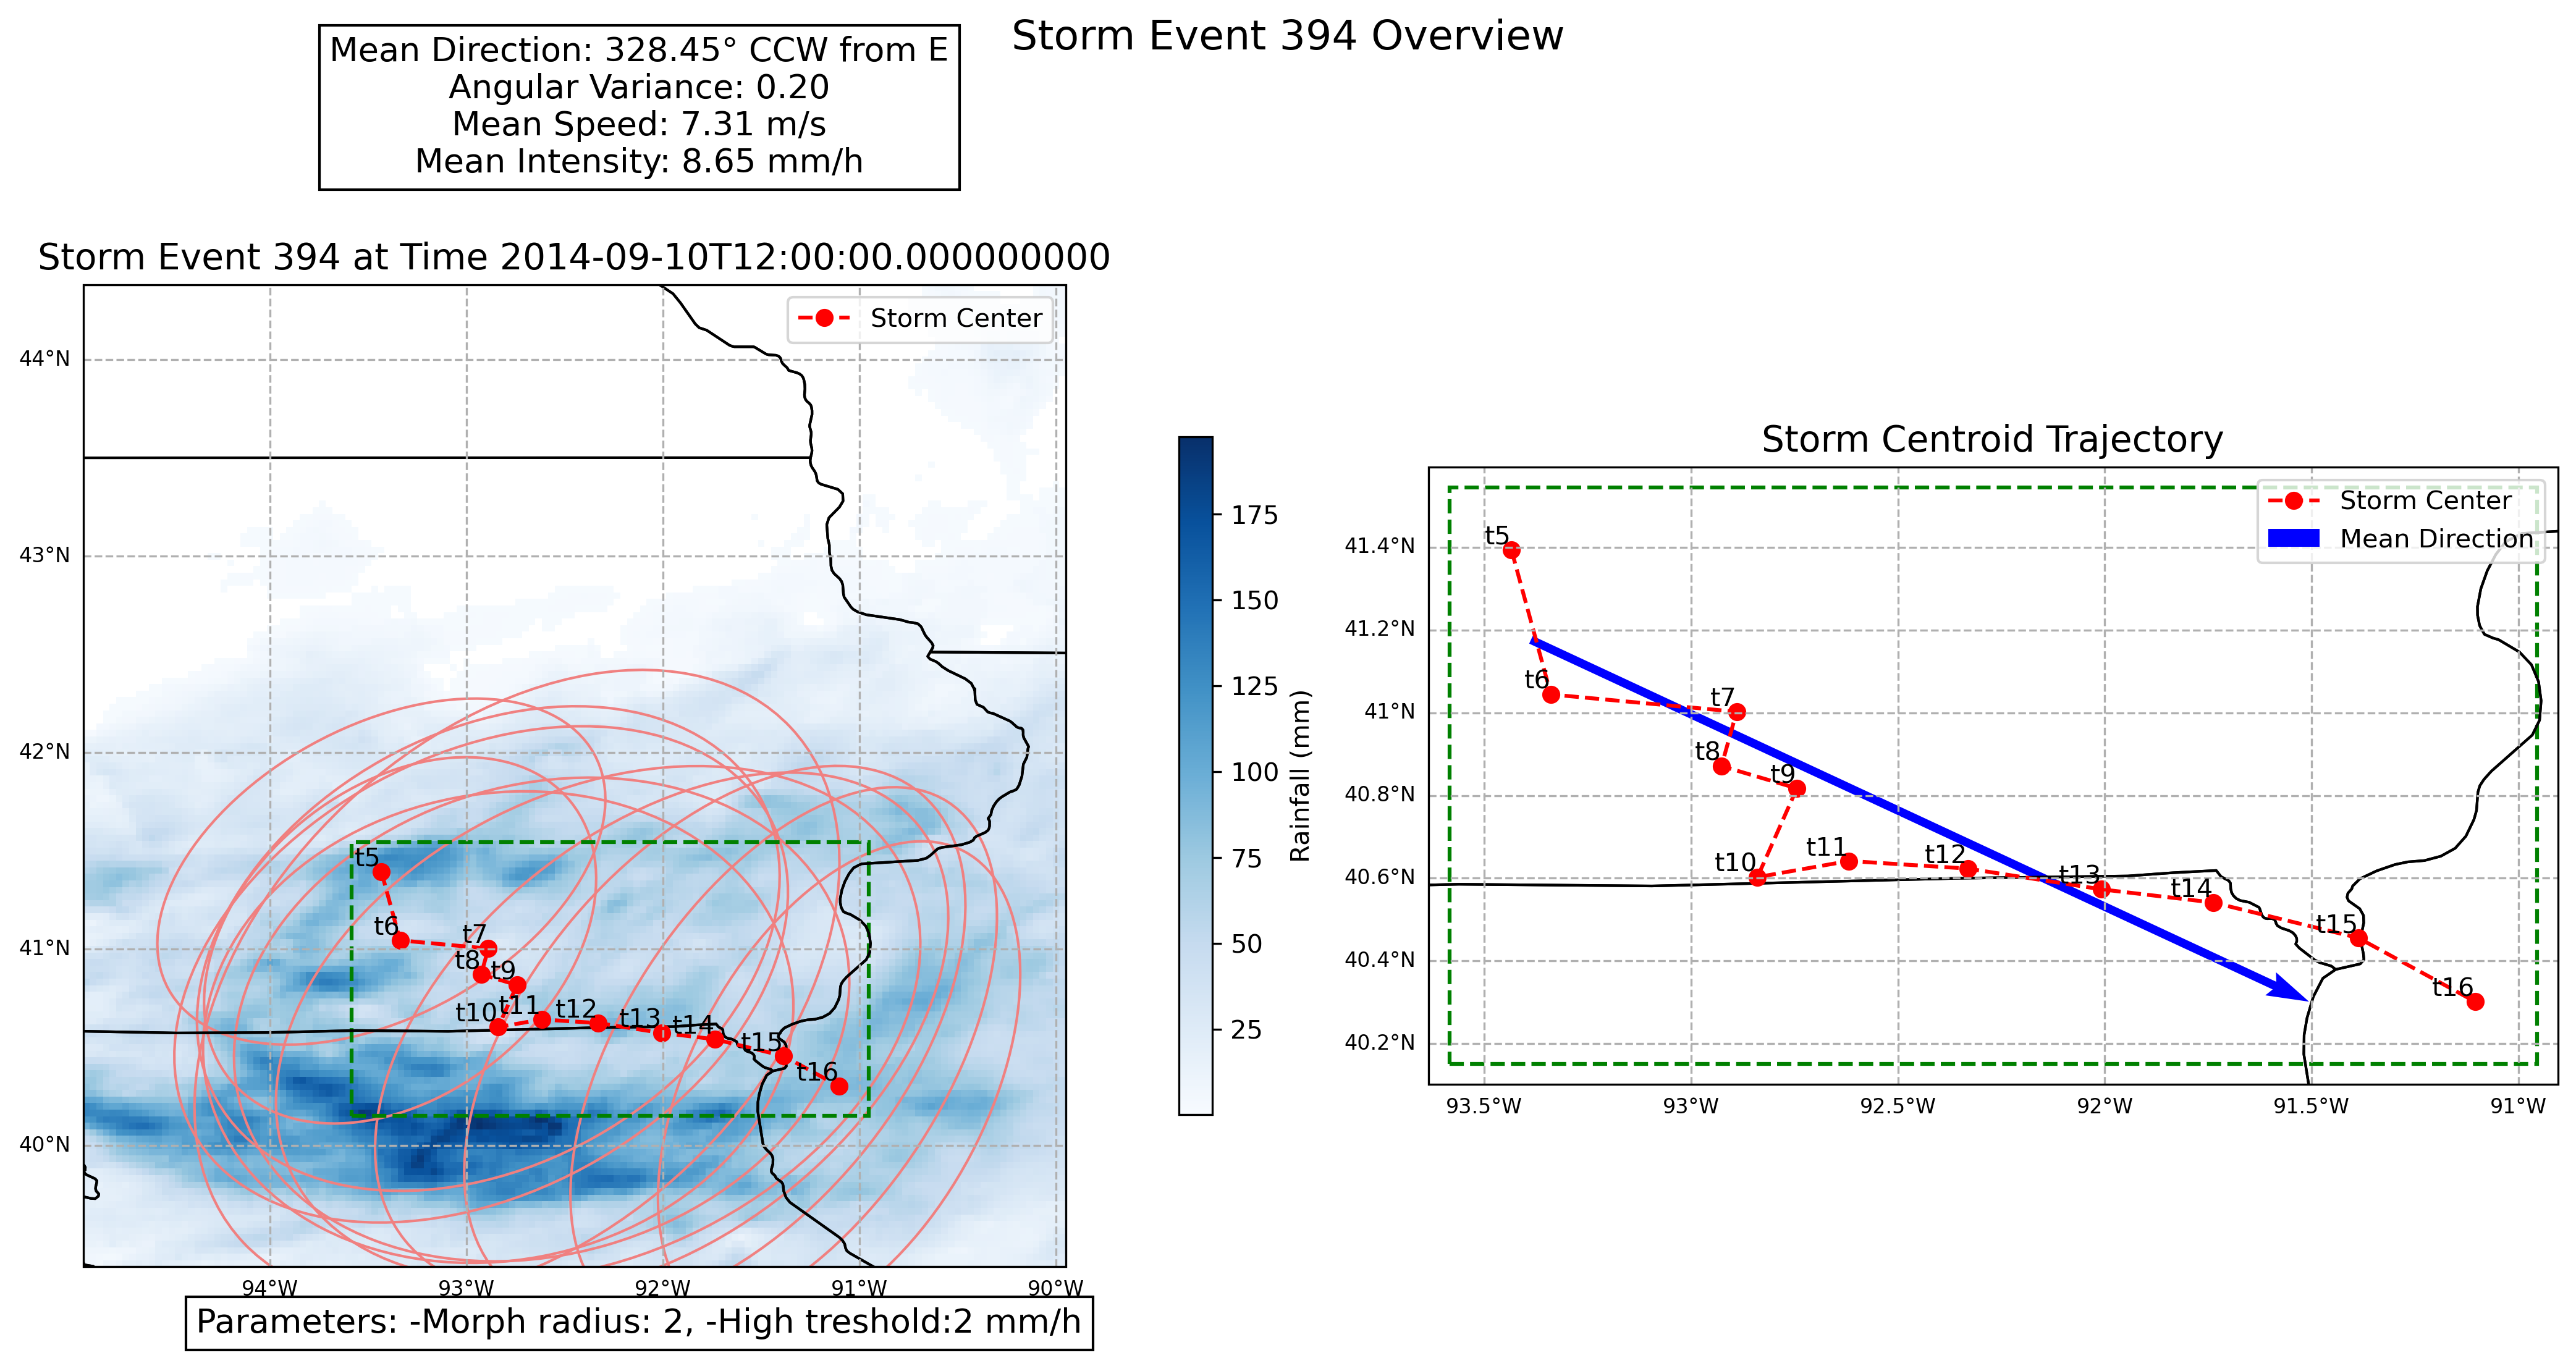

storm_step_394.png


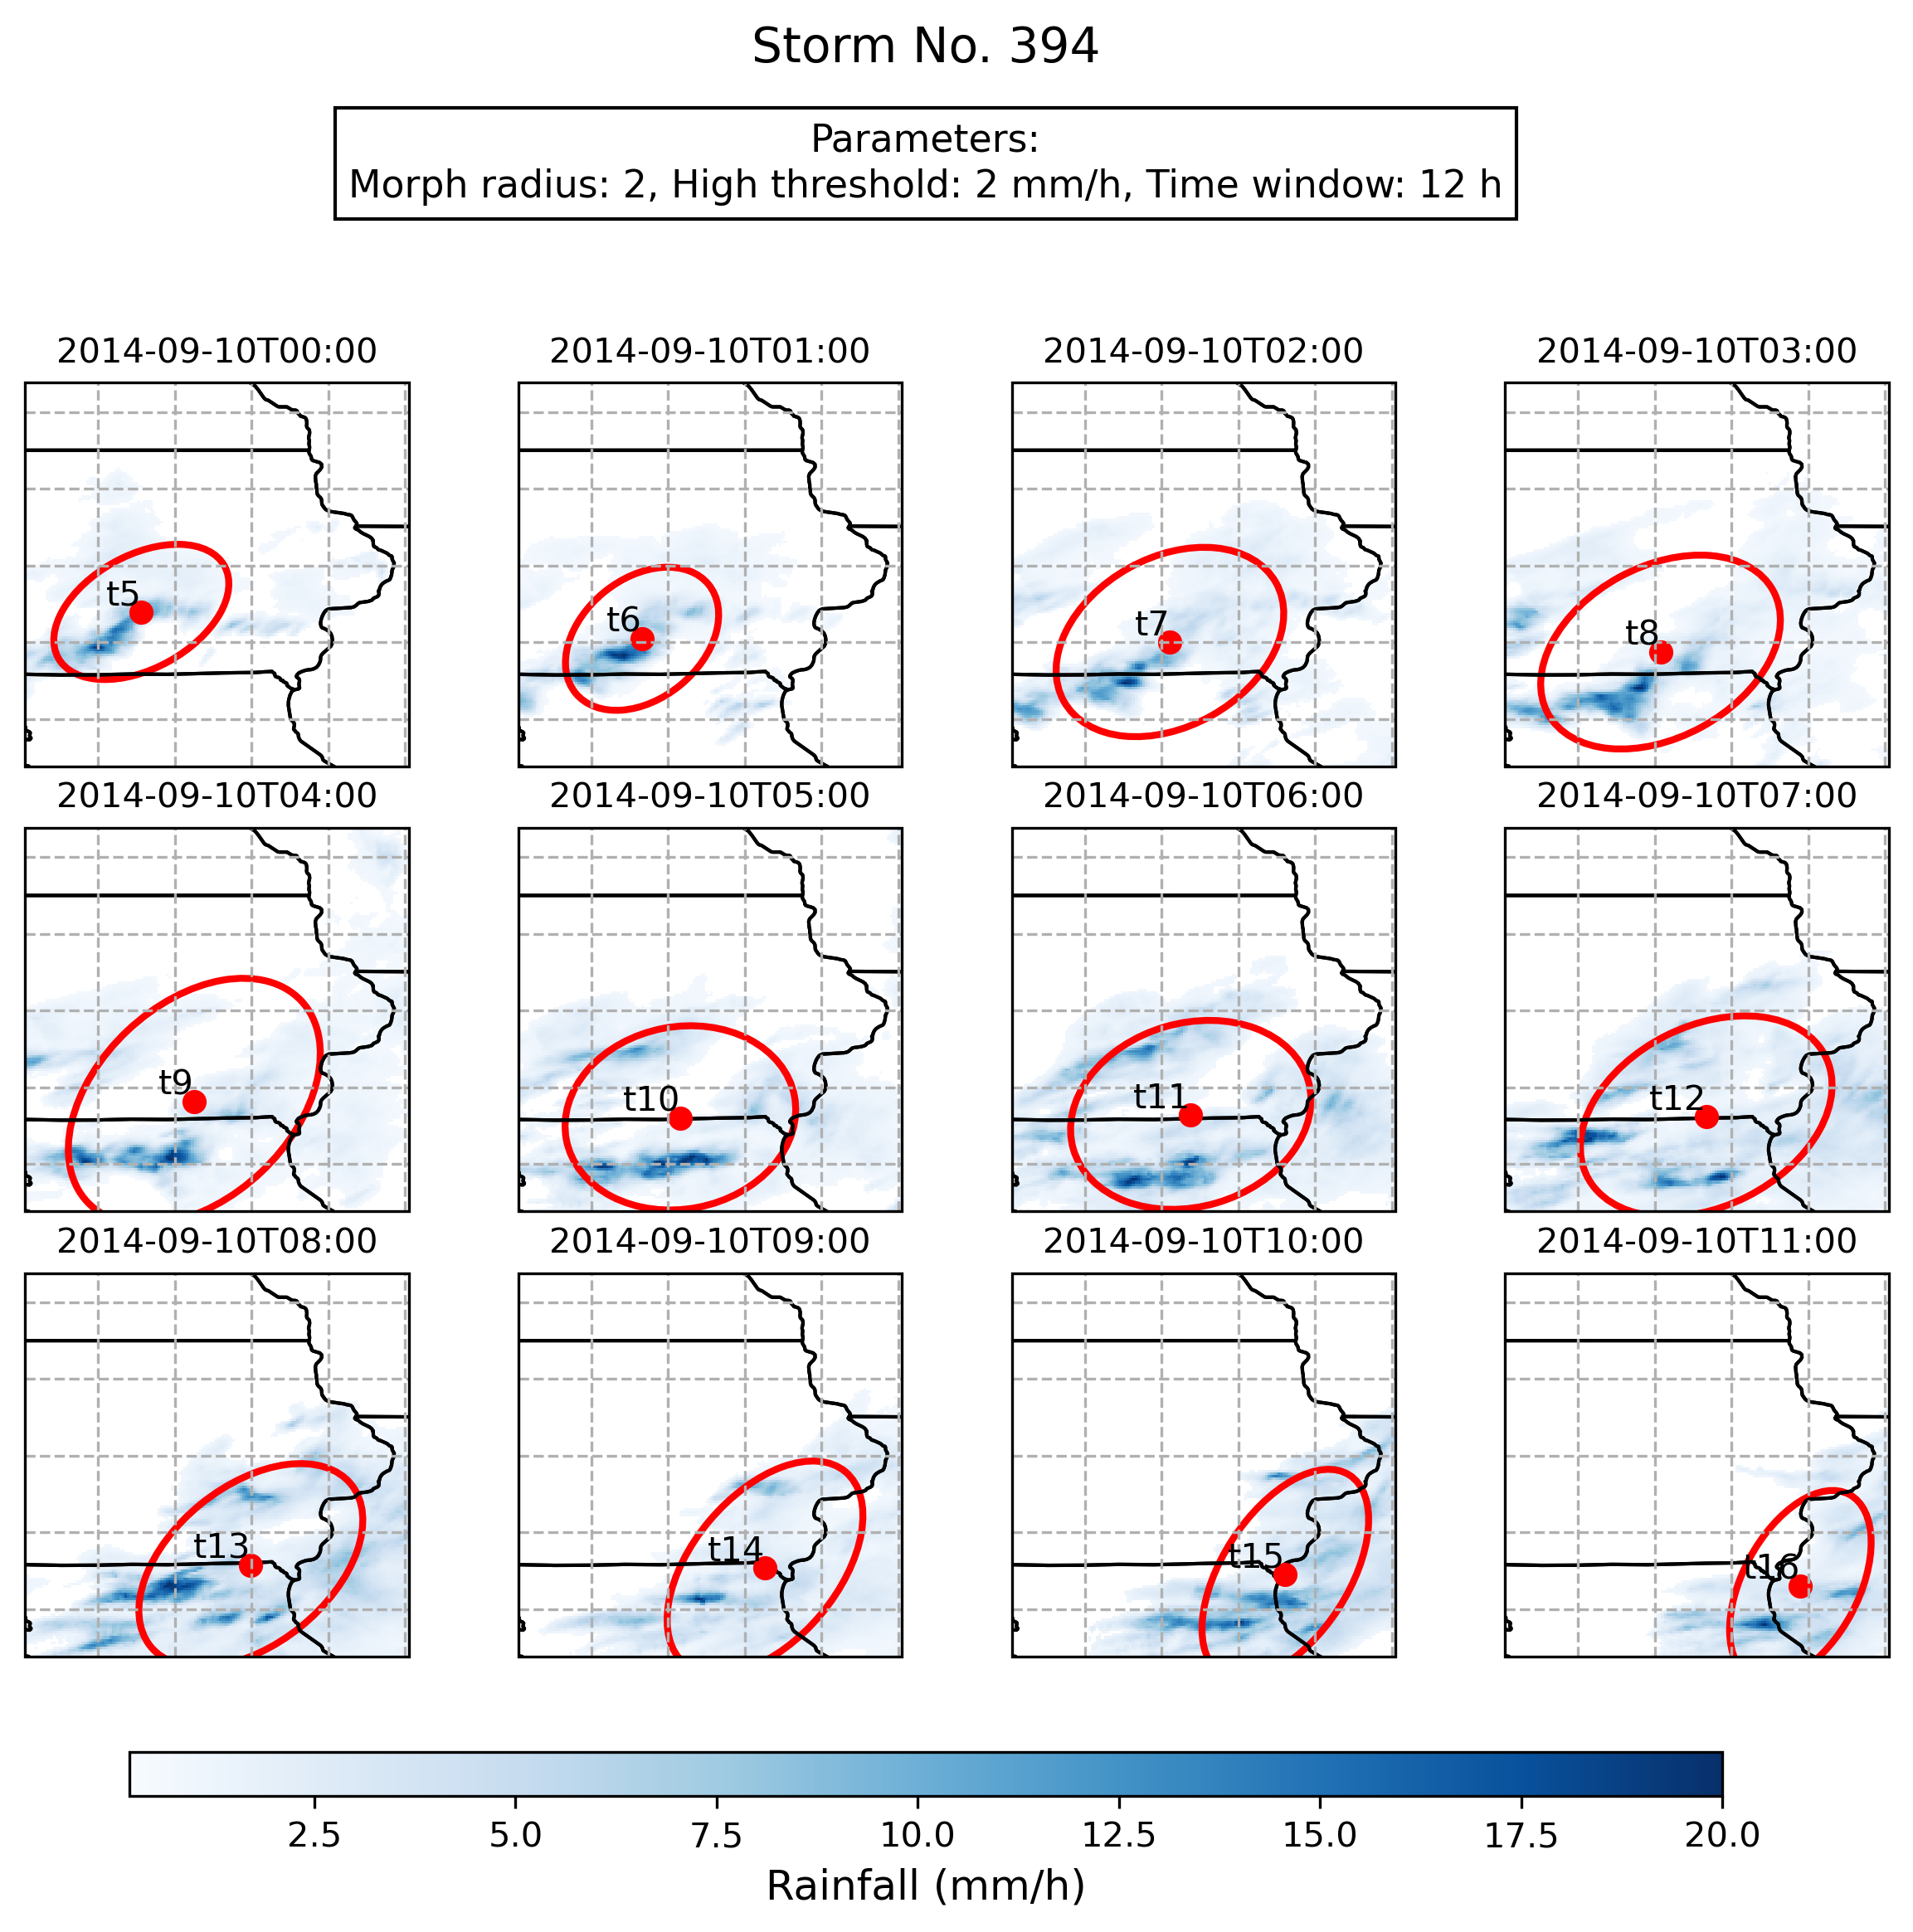

In [4]:
from IPython.display import Image, display
for p in figs:
    print(p.name)
    display(Image(filename=str(p)))

## 4. Storm-tracking animation (GIF)

Animate the tracking workflow for this storm: the **storm moving**, then the per-step
**fitted ellipse + growing centroid trail**, then the full **trajectory + mean-direction
vector + a statistics box** (direction, speed, rainfall intensity, angular variance).
Saved under `<output_dir>/<domain>/StormAnimation/`.

Headless equivalent: `pipeline.generate_event_animation(cfg, "<storm id/substring>")`.

The longest storm has a valid duration of 18 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2014-09-09T20:00:00.000000000 to 2014-09-10T13:00:00.000000000
Selected storm duration 18 hours
Saved storm-tracking animation for IOWA_Domain.nc_storm_394_20140909.nc:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormAnimation/storm_tracking_394.gif


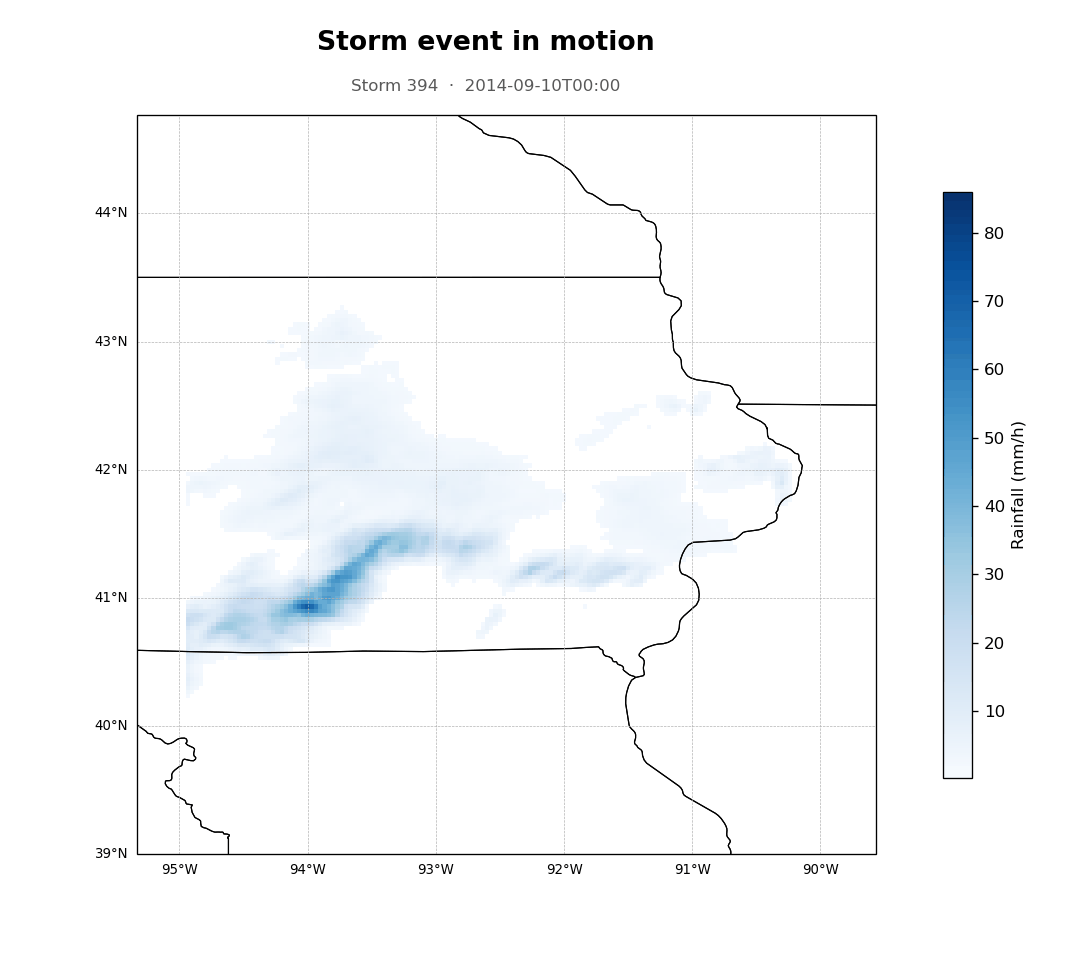

In [5]:
from IPython.display import Image, display

# Animate the tracking workflow for this storm (tunables: fps, hold_frames,
# rainfall_threshold, dpi). Saved under <output_dir>/<domain>/StormAnimation/.
gif_path = pipeline.generate_event_animation(cfg, storm, fps=4)
display(Image(filename=gif_path))